In [2]:
try: 
    import kagglehub #pip install kagglehub
    kagglehub.login()
    path = kagglehub.competition_download('aca-butterflies')
    print("Path to dataset files:", path)
    
except ImportError as e:
    from pathlib import Path
    path = Path().cwd()  / "aca-butterflies"

In [3]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
import torch.nn as nn
import torch.utils.data as data
import torchvision.transforms as transforms
import torch.nn.functional as F
from torchvision.transforms import v2
import numpy as np
import copy
import time

c:\Users\Xaneca\miniconda3\envs\ACA_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [4]:
BATCH_SIZE = 32
IMAGE_SIZE = 64

In [5]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

## First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [6]:
# load the data
img_dir = os.path.join(path, 'train')
df = pd.read_csv(os.path.join(path, 'train.csv'))

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
])

# encapsulate data into dataloader form
dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

### Train/Test 70/30 : Stratified

In [7]:
targets = dataset.img_labels['label'].values 

# Stratified: 70 / 30
train_indices, val_indices = train_test_split(
    range(len(dataset)),
    test_size=0.3,
    stratify=targets,
    random_state=42
)

# DATA AUGMENTATION FOR TRAINING SET
train_transform = v2.Compose([      # ⚠️ ver se aplica de maneira igual a todos as classes
    v2.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(15),
    v2.ToTensor(),
    # v2.Normalize((0.5,), (0.5,))
])

# Subsets
train_dataset = Subset(dataset, train_indices)
train_dataset.dataset = copy.copy(dataset)
train_dataset.dataset.transform = train_transform  # Apply augmentation only to training set
val_dataset = Subset(dataset, val_indices)

# DataLoaders
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Imagens para treino: {len(train_dataset)}")
print(f"Imagens para validação: {len(val_dataset)}")

Imagens para treino: 3639
Imagens para validação: 1560


c:\Users\Xaneca\miniconda3\envs\ACA_venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(


In [8]:
# VERIFY SAMPLES AND CLASSES
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


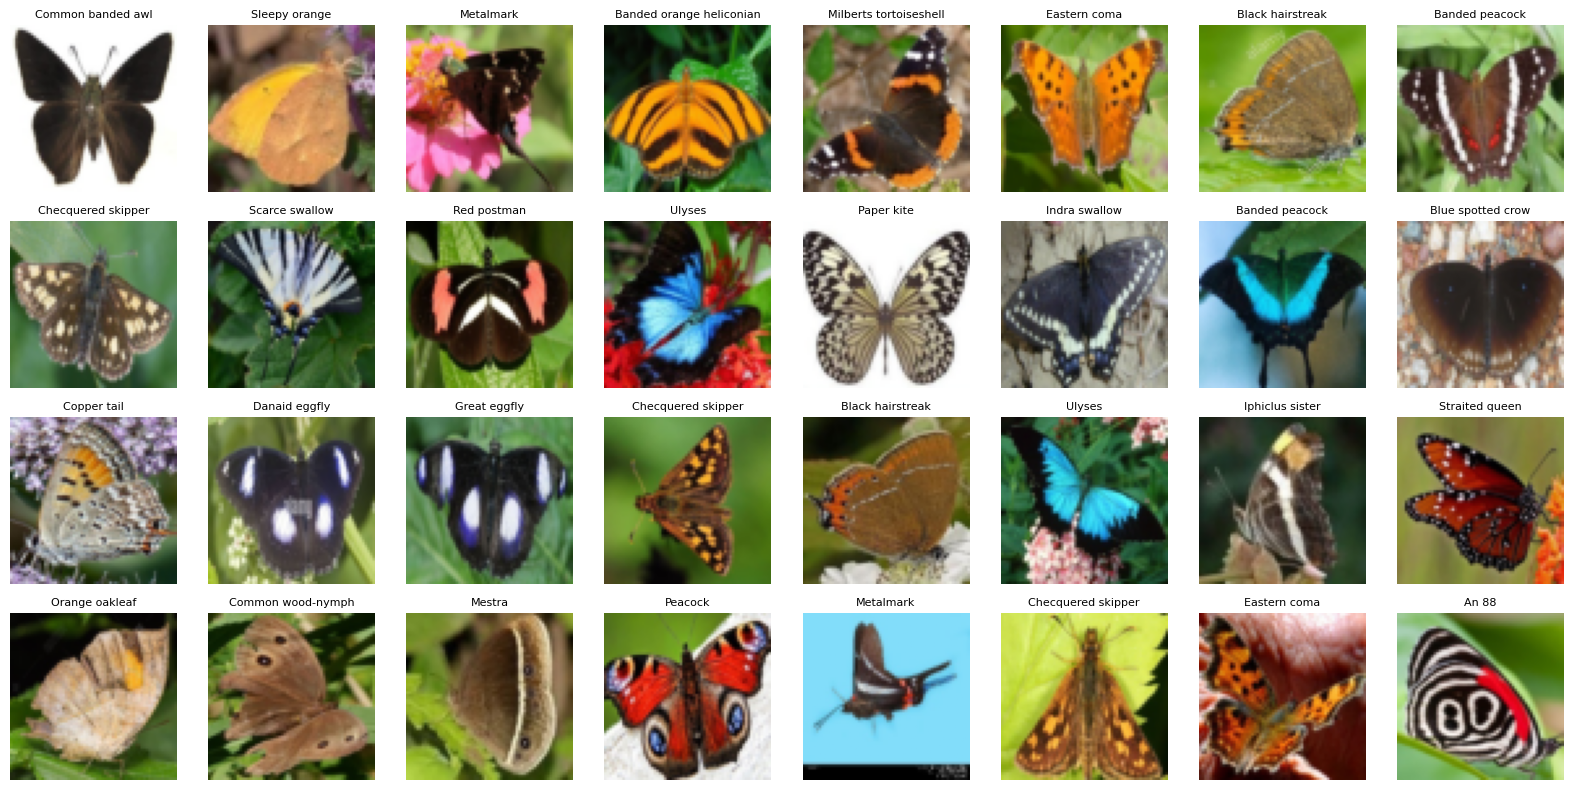

In [9]:
# Get a batch of images from the dataloader
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(len(images)):
    img = images[i].permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]

    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# MLP


In [11]:
# PL FROM CLASS MODIFIED
class ButterflyMLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, learning_rate=0.01, optimizer_cls=torch.optim.Adam, loss_fn=nn.CrossEntropyLoss, folder="Results/MLP/", filename=None, plot=True):
        super(ButterflyMLP, self).__init__()
        
        # STRUCTURE
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, num_classes)
        )
        
        # OPTIMIZER AND LOSS
        self.optimizer = optimizer_cls(self.parameters(), lr=learning_rate)
        self.criterion = loss_fn()
        self.filename = filename    # Name of CSV and PTH file
        self.folder = folder
        self.num_classes = num_classes
        self.plot = plot

        if filename == None:
            print("Warning: No filename provided. New name 'Untitled'")
            self.filename = "Untitled"

    def forward(self, x):
        # Flatten: transforma a imagem em vetor
        x = x.view(x.size(0), -1)
        return self.layers(x)

    def fit(self, train_dataloader, val_dataloader, epochs=10, patience=10):
        self.train() # Muda para modo de treino
        train_acc_graph = []
        val_acc_graph = []
        train_loss_graph = []
        val_loss_graph = []
        time_values = []
        p = 0
        best_loss_val = float('inf')
        best_acc_val = 0

        start_time = time.time()
        
        for epoch in range(epochs):
            total_loss = 0
            for images, labels in train_dataloader:
                self.optimizer.zero_grad()
                outputs = self.forward(images)

                #### BLOCO GEMINI ##### - Loss function MSE não faz softmax por isso temos que fazer manualmente
                if isinstance(self.criterion, nn.MSELoss):
                    # 1. Aplica Softmax para os valores ficarem entre 0 e 1 (como a sigmoid fazia)
                    probs = torch.softmax(outputs, dim=1)
                    # 2. Transforma labels em One-Hot para o MSE conseguir comparar vetores
                    targets_one_hot = F.one_hot(labels, num_classes=self.num_classes).float()
                    loss = self.criterion(probs, targets_one_hot)
                else:
                    # CrossEntropyLoss faz tudo isto sozinha
                    loss = self.criterion(outputs, labels)
                #######################
                
                loss.backward()
                self.optimizer.step()
                
                total_loss += loss.item()

            val_acc, val_loss = self.evaluate(val_dataloader)
            train_acc, _ = self.evaluate(train_dataloader)
            train_loss = total_loss / len(train_dataloader)

            if val_loss < best_loss_val:
                best_loss_val = val_loss
                best_acc_val = val_acc
                p = 0
                torch.save(self.state_dict(), self.folder + self.filename + ".pth")
            else:
                p += 1
            
            if p >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

            train_loss_graph.append(train_loss)
            train_acc_graph.append(train_acc)
            val_acc_graph.append(val_acc)
            val_loss_graph.append(val_loss)
            time_values.append(time.time() - start_time)
            self.train()

            print(f"Época [{epoch+1}/{epochs}] - Train Loss: {total_loss/len(train_dataloader):.4f} - Train Accuracy: {train_acc:.2f}% - Val Loss: {val_loss:.4f} - Val Accuracy: {val_acc:.2f}%")
        
        end_time = time.time()
        print(f"Tempo total de treinamento: {end_time - start_time:.2f} segundos")

        plt.figure()
        plt.plot(train_acc_graph, label='Train Accuracy')
        plt.plot(val_acc_graph, label='Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.title('Train vs Validation Accuracy')
        plt.legend()
        plt.savefig(self.folder + self.filename + "_accuracy.png")
        if self.plot:
            plt.show()
        else:
            plt.close()

        plt.figure()
        plt.plot(train_loss_graph, label='Train Loss')
        plt.plot(val_loss_graph, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Train vs Validation Loss')
        plt.legend()
        plt.savefig(self.folder + self.filename + "_loss.png")
        if self.plot:
            plt.show()
        else:
            plt.close()

        df = pd.DataFrame({"train_acc": train_acc_graph, "val_acc": val_acc_graph, "train_loss": train_loss_graph, "val_loss": val_loss_graph, "time": time_values})
        df.to_csv(self.folder + self.filename + ".csv", index=True, index_label="epoch")

        return {
            "best_val_loss": best_loss_val,
            "best_val_acc": best_acc_val,
            "total_time": end_time - start_time,
            "epochs_used": epoch + 1
        }

    def predict(self, dataloader):
        """ Método para prever várias imagens de uma vez """
        self.eval() # Muda para modo de teste (desliga dropout etc)
        all_preds = []
        
        with torch.no_grad(): # Desliga o cálculo de gradientes (mais rápido)
            for images, labels in dataloader:
                outputs = self.forward(images)
                # Pega o índice da classe com maior valor (probabilidade)
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.numpy())

        return all_preds
    
    def evaluate(self, loader):
        self.eval()
        todas_preds = []
        todas_labels = []
        total_loss = 0
        
        with torch.no_grad():
            for images, labels in loader:
                # Usamos self(images) para chamar o forward do próprio modelo
                outputs = self(images) 

                # ------- GEMINI ------
                if isinstance(self.criterion, nn.MSELoss):
                    probs = torch.softmax(outputs, dim=1)
                    targets_one_hot = F.one_hot(labels, num_classes=self.num_classes).float()
                    loss = self.criterion(probs, targets_one_hot)
                else:
                    loss = self.criterion(outputs, labels)
                # ---------------------

                total_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                
                todas_preds.extend(predicted.cpu().numpy())
                todas_labels.extend(labels.cpu().numpy())
        
        avg_loss = total_loss / len(loader)
        accuracy = (np.array(todas_preds) == np.array(todas_labels)).mean() * 100
        return accuracy, avg_loss

### Baseline

In [12]:
num_inputs = IMAGE_SIZE * IMAGE_SIZE * 3
num_classes = len(dataset.classes)
hidden_size = 128

Época [1/100] - Train Loss: 4.3001 - Train Accuracy: 3.54% - Val Loss: 4.2493 - Val Accuracy: 2.88%
Época [2/100] - Train Loss: 4.1011 - Train Accuracy: 4.84% - Val Loss: 4.0013 - Val Accuracy: 5.06%
Época [3/100] - Train Loss: 3.8889 - Train Accuracy: 9.34% - Val Loss: 3.7326 - Val Accuracy: 9.68%
Época [4/100] - Train Loss: 3.5054 - Train Accuracy: 13.05% - Val Loss: 3.4876 - Val Accuracy: 12.12%
Época [5/100] - Train Loss: 3.2263 - Train Accuracy: 19.81% - Val Loss: 3.1993 - Val Accuracy: 18.14%
Época [6/100] - Train Loss: 3.0694 - Train Accuracy: 20.72% - Val Loss: 3.1034 - Val Accuracy: 19.81%
Época [7/100] - Train Loss: 2.9698 - Train Accuracy: 24.21% - Val Loss: 2.9925 - Val Accuracy: 22.82%
Época [8/100] - Train Loss: 2.8448 - Train Accuracy: 27.10% - Val Loss: 2.8991 - Val Accuracy: 24.87%
Época [9/100] - Train Loss: 2.7688 - Train Accuracy: 25.80% - Val Loss: 2.9486 - Val Accuracy: 23.08%
Época [10/100] - Train Loss: 2.7096 - Train Accuracy: 29.21% - Val Loss: 2.8421 - Val Ac

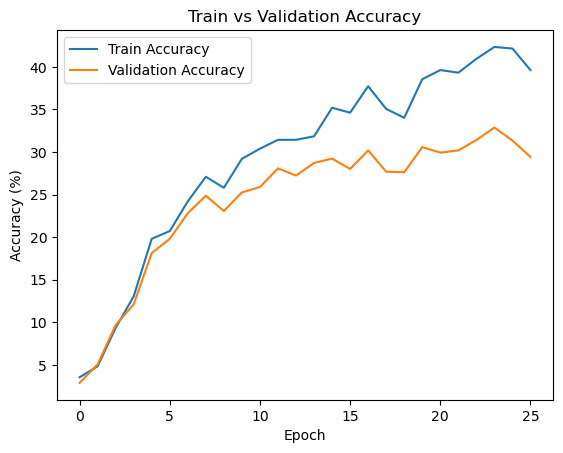

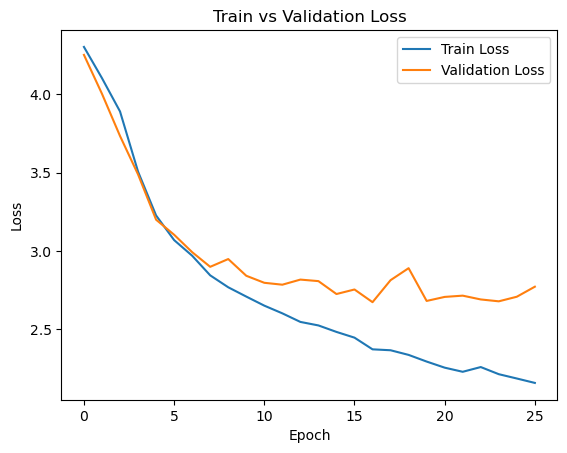

In [ ]:
                    #   input_size, hidden_size, num_classes, learning_rate=0.01, optimizer_cls=torch.optim.Adam, loss_fn_cls=nn.CrossEntropyLoss, folder="Results/MLP/", filename=None):
mlp = ButterflyMLP(num_inputs, hidden_size, num_classes, learning_rate=0.001, folder="Results/MLP/baseline", filename="MLP_Baseline")
mlp.fit(train_loader, val_loader, epochs=100, patience=10)
# predictions = mlp.predict(val_loader)
# predictions


## Hyperparameters

### Best Learning Rate

In [13]:
# PARAMETERS
num_inputs = IMAGE_SIZE * IMAGE_SIZE * 3
num_classes = len(dataset.classes)
hidden_size = 128
PATIENCE = 10
MAX_EPOCHS = 100

# TESTING LEARNING RATES
lr = [0.1, 0.01, 0.001, 0.0001]
LR_NAME = ["0_1", "0_01", "0_001", "0_0001"]

Época [1/100] - Train Loss: 59.0899 - Train Accuracy: 1.35% - Val Loss: 4.3378 - Val Accuracy: 1.35%
Época [2/100] - Train Loss: 4.3521 - Train Accuracy: 2.01% - Val Loss: 4.3311 - Val Accuracy: 2.05%
Época [3/100] - Train Loss: 4.3537 - Train Accuracy: 1.54% - Val Loss: 4.3394 - Val Accuracy: 1.54%
Época [4/100] - Train Loss: 4.3531 - Train Accuracy: 1.43% - Val Loss: 4.3408 - Val Accuracy: 1.41%
Época [5/100] - Train Loss: 4.3606 - Train Accuracy: 1.32% - Val Loss: 4.3348 - Val Accuracy: 1.35%
Época [6/100] - Train Loss: 4.3572 - Train Accuracy: 2.01% - Val Loss: 4.3342 - Val Accuracy: 2.05%
Época [7/100] - Train Loss: 4.3546 - Train Accuracy: 2.01% - Val Loss: 4.3425 - Val Accuracy: 2.05%
Época [8/100] - Train Loss: 4.3596 - Train Accuracy: 1.43% - Val Loss: 4.3389 - Val Accuracy: 1.47%
Época [9/100] - Train Loss: 4.3563 - Train Accuracy: 2.01% - Val Loss: 4.3403 - Val Accuracy: 2.05%
Época [10/100] - Train Loss: 4.3589 - Train Accuracy: 1.46% - Val Loss: 4.3344 - Val Accuracy: 1.47

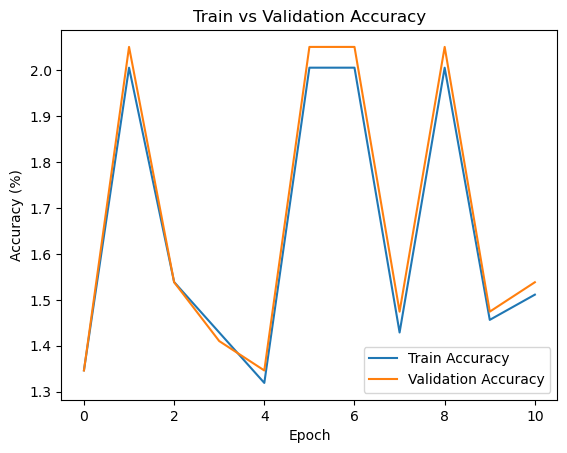

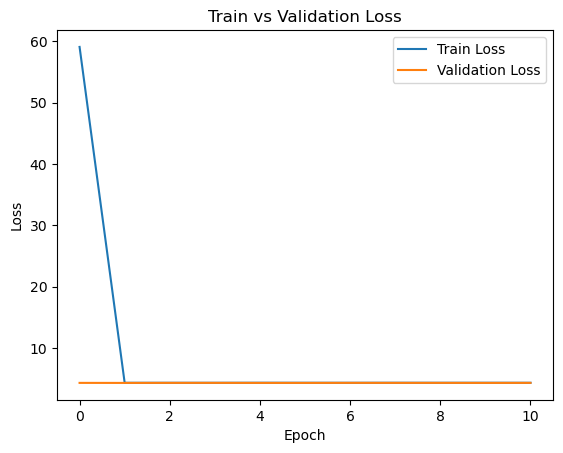

Época [1/100] - Train Loss: 4.8914 - Train Accuracy: 2.01% - Val Loss: 4.3147 - Val Accuracy: 2.05%
Época [2/100] - Train Loss: 4.3198 - Train Accuracy: 2.01% - Val Loss: 4.3128 - Val Accuracy: 2.05%
Época [3/100] - Train Loss: 4.3183 - Train Accuracy: 2.01% - Val Loss: 4.3122 - Val Accuracy: 2.05%
Época [4/100] - Train Loss: 4.3181 - Train Accuracy: 2.01% - Val Loss: 4.3119 - Val Accuracy: 2.05%
Época [5/100] - Train Loss: 4.3183 - Train Accuracy: 2.01% - Val Loss: 4.3119 - Val Accuracy: 2.05%
Época [6/100] - Train Loss: 4.3181 - Train Accuracy: 2.01% - Val Loss: 4.3118 - Val Accuracy: 2.05%
Época [7/100] - Train Loss: 4.3185 - Train Accuracy: 2.01% - Val Loss: 4.3120 - Val Accuracy: 2.05%
Época [8/100] - Train Loss: 4.3187 - Train Accuracy: 2.01% - Val Loss: 4.3119 - Val Accuracy: 2.05%
Época [9/100] - Train Loss: 4.3183 - Train Accuracy: 2.01% - Val Loss: 4.3119 - Val Accuracy: 2.05%
Época [10/100] - Train Loss: 4.3184 - Train Accuracy: 2.01% - Val Loss: 4.3119 - Val Accuracy: 2.05%

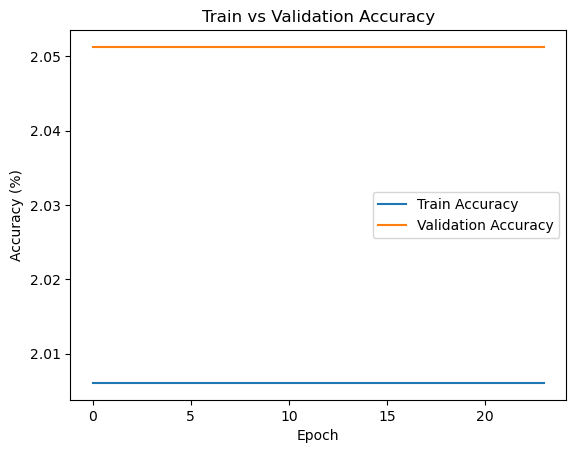

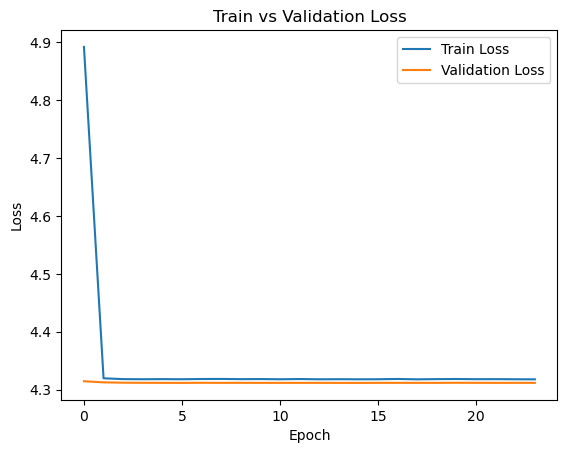

Época [1/100] - Train Loss: 4.2333 - Train Accuracy: 4.75% - Val Loss: 4.0432 - Val Accuracy: 4.81%
Época [2/100] - Train Loss: 3.7885 - Train Accuracy: 8.30% - Val Loss: 3.6936 - Val Accuracy: 8.65%
Época [3/100] - Train Loss: 3.5199 - Train Accuracy: 11.60% - Val Loss: 3.5102 - Val Accuracy: 11.35%
Época [4/100] - Train Loss: 3.3787 - Train Accuracy: 14.32% - Val Loss: 3.4160 - Val Accuracy: 12.69%
Época [5/100] - Train Loss: 3.2393 - Train Accuracy: 16.74% - Val Loss: 3.2732 - Val Accuracy: 16.28%
Época [6/100] - Train Loss: 3.1476 - Train Accuracy: 21.60% - Val Loss: 3.1736 - Val Accuracy: 20.00%
Época [7/100] - Train Loss: 2.9952 - Train Accuracy: 22.81% - Val Loss: 3.0585 - Val Accuracy: 21.09%
Época [8/100] - Train Loss: 2.8877 - Train Accuracy: 21.93% - Val Loss: 3.1390 - Val Accuracy: 19.49%
Época [9/100] - Train Loss: 2.8175 - Train Accuracy: 22.70% - Val Loss: 3.1068 - Val Accuracy: 20.83%
Época [10/100] - Train Loss: 2.7531 - Train Accuracy: 28.22% - Val Loss: 2.8814 - Val 

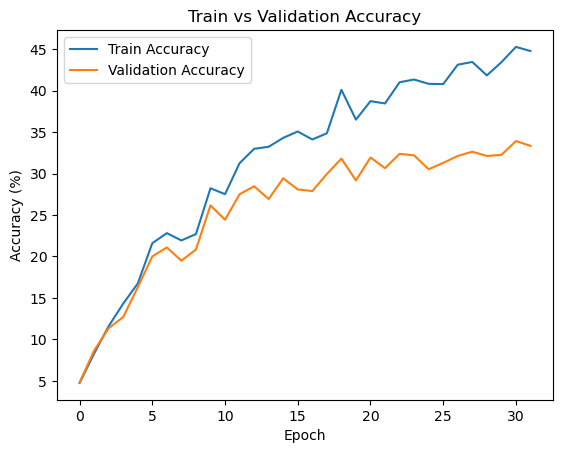

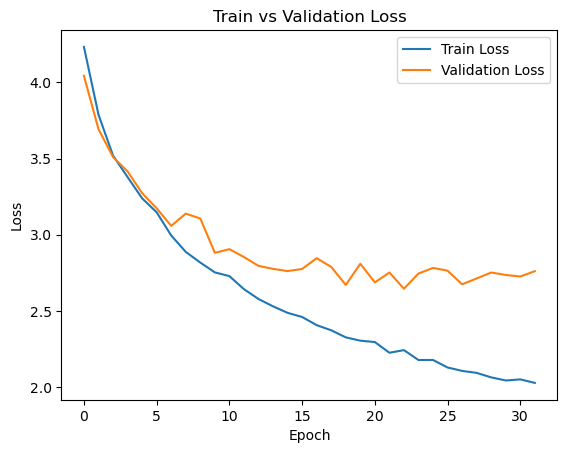

Época [1/100] - Train Loss: 4.3099 - Train Accuracy: 2.09% - Val Loss: 4.2957 - Val Accuracy: 1.73%
Época [2/100] - Train Loss: 4.2547 - Train Accuracy: 3.19% - Val Loss: 4.2246 - Val Accuracy: 3.14%
Época [3/100] - Train Loss: 4.1770 - Train Accuracy: 3.24% - Val Loss: 4.1348 - Val Accuracy: 3.01%
Época [4/100] - Train Loss: 4.0757 - Train Accuracy: 5.66% - Val Loss: 4.0220 - Val Accuracy: 5.13%
Época [5/100] - Train Loss: 3.9481 - Train Accuracy: 8.41% - Val Loss: 3.8945 - Val Accuracy: 8.21%
Época [6/100] - Train Loss: 3.8105 - Train Accuracy: 10.00% - Val Loss: 3.7609 - Val Accuracy: 8.91%
Época [7/100] - Train Loss: 3.6866 - Train Accuracy: 11.57% - Val Loss: 3.6629 - Val Accuracy: 10.64%
Época [8/100] - Train Loss: 3.5893 - Train Accuracy: 11.79% - Val Loss: 3.5792 - Val Accuracy: 11.60%
Época [9/100] - Train Loss: 3.5140 - Train Accuracy: 12.42% - Val Loss: 3.5259 - Val Accuracy: 10.90%
Época [10/100] - Train Loss: 3.4598 - Train Accuracy: 13.82% - Val Loss: 3.4684 - Val Accurac

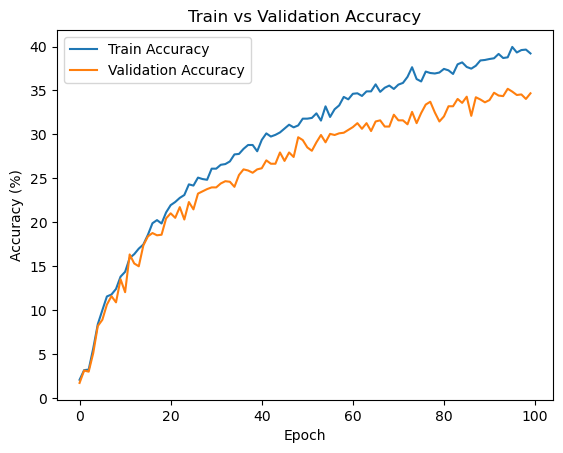

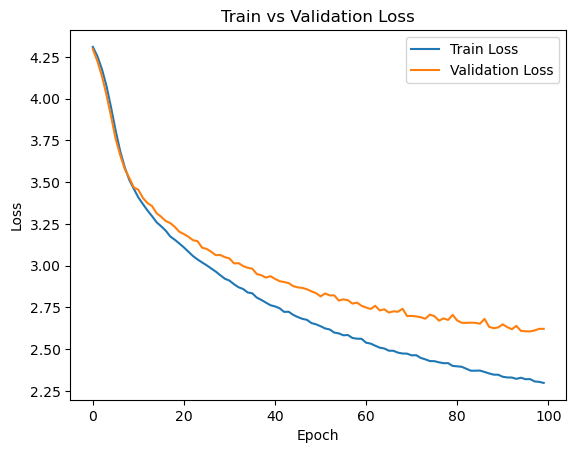

In [ ]:
best_loss_lr = float('inf')
best_lr = 0.1
os.makedirs("Results/MLP/learning_rate/", exist_ok=True)
path = "Results/MLP/learning_rate/"

for learning_rate, lr_name in zip(lr, LR_NAME):
    mlp = ButterflyMLP(num_inputs, hidden_size, num_classes, learning_rate=learning_rate, folder=path + f"lr_{lr_name}/", filename=f"lr_{lr_name}")
    results = mlp.fit(train_loader, val_loader, epochs=MAX_EPOCHS, patience=PATIENCE)

    if results["best_val_loss"] < best_loss_lr:
        best_loss_lr = results["best_val_loss"]
        best_lr = learning_rate


### Best Loss Function

In [14]:
best_loss_lr = float('inf')
best_lr = 0.1
best_acc_lr = 0.0
path = "Results/MLP/learning_rate/"

for learning_rate, lr_name in zip(lr, LR_NAME):
    mlp = ButterflyMLP(num_inputs, hidden_size, num_classes, learning_rate=learning_rate, folder=f"Results/MLP/learning_rate/lr_{lr_name}/", filename=f"lr_{lr_name}")
    
    pesos = torch.load(path + f"lr_{lr_name}/lr_{lr_name}.pth")
    mlp.load_state_dict(pesos)
    acc, loss = mlp.evaluate(val_loader)
    print(f"Learning Rate: {learning_rate} - Val Acc: {acc:.4f} - Val Loss: {loss:.4f}")
    if loss < best_loss_lr:
        best_loss_lr = loss
        best_lr = learning_rate
        best_acc_lr = acc

print(f"Best Learning Rate: {best_lr} - Best Val Acc: {best_acc_lr:.4f} - Best Val Loss: {best_loss_lr:.4f}")

Learning Rate: 0.1 - Val Acc: 2.0513 - Val Loss: 4.3311
Learning Rate: 0.01 - Val Acc: 2.0513 - Val Loss: 4.3118
Learning Rate: 0.001 - Val Acc: 32.3718 - Val Loss: 2.6458
Learning Rate: 0.0001 - Val Acc: 34.4872 - Val Loss: 2.6058
Best Learning Rate: 0.0001 - Best Val Acc: 34.4872 - Best Val Loss: 2.6058


In [ ]:
loss_functions = [nn.CrossEntropyLoss, nn.MSELoss, nn.MultiMarginLoss]
# loss_names = ["CrossEntropyLoss", "MSELoss", "MultiMarginLoss"]
loss_names = ["MSELoss", "MultiMarginLoss"]
os.makedirs("Results/MLP/loss_function/", exist_ok=True)
path = "Results/MLP/loss_function/"
learning_rate = best_lr

# TESTING LOSS FUNCTIONS
best_loss_fn = float('inf')
best_loss_fn_name = ""

for lf, lf_name in zip(loss_functions, loss_names):
    print(f"Testing Loss Function: {lf_name} with {learning_rate} learning rate")
    os.makedirs(path + f"lf_{lf_name}/", exist_ok=True)
    mlp = ButterflyMLP(num_inputs, hidden_size, num_classes, learning_rate=learning_rate, loss_fn=lf, folder=path+f"lf_{lf_name}/", filename=f"lf_{lf_name}")
    results = mlp.fit(train_loader, val_loader, epochs=MAX_EPOCHS, patience=PATIENCE)

    if results["best_val_loss"] < best_loss_fn:
        best_loss_fn = results["best_val_loss"]
        best_loss_fn_name = lf_name

### Best Optimizer

In [ ]:
loss_functions = [nn.CrossEntropyLoss, nn.MSELoss, nn.MultiMarginLoss]
loss_names = ["CrossEntropyLoss", "MSELoss", "MultiMarginLoss"]

best_loss_lr = float('inf')
best_lr = 0.1
best_acc_lr = 0.0
path = "Results/MLP/loss_function/"

for learning_rate, lr_name in zip(lr, LR_NAME):
    mlp = ButterflyMLP(num_inputs, hidden_size, num_classes, learning_rate=learning_rate, folder=f"Results/MLP/loss_function/lf_{lr_name}/", filename=f"lf_{lr_name}")
    
    pesos = torch.load(path + f"lr_{lr_name}/lr_{lr_name}.pth")
    mlp.load_state_dict(pesos)
    acc, loss = mlp.evaluate(val_loader)
    print(f"Learning Rate: {learning_rate} - Val Acc: {acc:.4f} - Val Loss: {loss:.4f}")
    if loss < best_loss_lr:
        best_loss_lr = loss
        best_lr = learning_rate
        best_acc_lr = acc

print(f"Best Learning Rate: {best_lr} - Best Val Acc: {best_acc_lr:.4f} - Best Val Loss: {best_loss_lr:.4f}")

### Best Hidden Size

# Optuna

In [14]:
num_inputs = IMAGE_SIZE * IMAGE_SIZE * 3
num_classes = len(dataset.classes)
hidden_size = 128

In [13]:
MAX_EPOCHS = 70
PATIENCE = 10
NUM_TRIALS = 30

In [15]:
import optuna

def objective(trial):
    losses = {  # guarda as classes, nao as instancias
        'CrossEntropy': nn.CrossEntropyLoss,
        # 'MSE': nn.MSELoss,
        'MultiMargin': nn.MultiMarginLoss
    }

    opt = { # guarda as classes, nao as instancias
        'ADAM': torch.optim.Adam,
        'RMS': torch.optim.RMSprop,
        # 'SGD': torch.optim.SGD
    }

    LEARNING_RATE = trial.suggest_categorical('learning_rate', [1e-4, 1e-3, 1e-2, 1e-1])
    
    loss_name = trial.suggest_categorical('loss_fn', list(losses.keys()))
    criterion = losses[loss_name]

    opt_name = trial.suggest_categorical('optimizer', list(opt.keys()))
    optimizer = opt[opt_name]

    HIDDEN_SIZE = trial.suggest_categorical('hidden_size', [128,256,512,1024])

    print(f"Params: LR={LEARNING_RATE}, Loss={loss_name}, Opt={opt_name}, Hidden Size={HIDDEN_SIZE}")

    mlp = ButterflyMLP(num_inputs,
                       HIDDEN_SIZE,
                       num_classes,
                       learning_rate=LEARNING_RATE,
                       loss_fn=criterion,
                       optimizer_cls=optimizer,
                       folder=f"Results/MLP/optuna_3_acc/",
                       filename=f"trial_{trial.number}",
                       plot=False)
    results = mlp.fit(train_loader, val_loader, epochs=MAX_EPOCHS, patience=PATIENCE)

    trial.set_user_attr("epochs_used", results["epochs_used"])

    # menor loss possivel
    return results['best_val_acc'] #, results['best_val_acc']

folder_path = "Results/MLP/optuna_3_acc/"

study = optuna.create_study(study_name="MLP_study_acc",
                            direction="maximize",
                            sampler=optuna.samplers.TPESampler(),   # ou GaussianProcessSampler (GP)
                            storage=f"sqlite:///{folder_path}optuna_mlp_study_3_acc.db",
                            pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
                            load_if_exists=True)

study.optimize(objective, n_trials=NUM_TRIALS)

print("\n" + "="*30)
print("BEST TRIAL RESULTS")
print("="*30)

print(f"Best Trial: #{study.best_trial.number}")
print(f"Best Accuracy Achieved: {study.best_trial.value:.4f}")

print("\nBest Hyperparameters Found:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

print("="*30)

[I 2026-04-10 16:34:52,524] A new study created in RDB with name: MLP_study_acc


Params: LR=0.1, Loss=MultiMargin, Opt=ADAM, Hidden Size=256
Época [1/70] - Train Loss: 29.2185 - Train Accuracy: 1.51% - Val Loss: 0.9626 - Val Accuracy: 1.54%
Época [2/70] - Train Loss: 1.0027 - Train Accuracy: 1.51% - Val Loss: 0.9654 - Val Accuracy: 1.54%
Época [3/70] - Train Loss: 1.0101 - Train Accuracy: 2.01% - Val Loss: 0.9627 - Val Accuracy: 2.05%
Época [4/70] - Train Loss: 1.0048 - Train Accuracy: 2.01% - Val Loss: 0.9656 - Val Accuracy: 2.05%
Época [5/70] - Train Loss: 1.0058 - Train Accuracy: 2.01% - Val Loss: 0.9645 - Val Accuracy: 2.05%
Época [6/70] - Train Loss: 1.0034 - Train Accuracy: 1.62% - Val Loss: 0.9634 - Val Accuracy: 1.67%
Época [7/70] - Train Loss: 1.0021 - Train Accuracy: 1.54% - Val Loss: 0.9631 - Val Accuracy: 1.54%
Época [8/70] - Train Loss: 1.0079 - Train Accuracy: 1.62% - Val Loss: 0.9636 - Val Accuracy: 1.67%
Época [9/70] - Train Loss: 0.9995 - Train Accuracy: 2.01% - Val Loss: 0.9639 - Val Accuracy: 2.05%
Época [10/70] - Train Loss: 1.0080 - Train Accur

[I 2026-04-10 16:39:07,323] Trial 0 finished with value: 1.5384615384615385 and parameters: {'learning_rate': 0.1, 'loss_fn': 'MultiMargin', 'optimizer': 'ADAM', 'hidden_size': 256}. Best is trial 0 with value: 1.5384615384615385.


Params: LR=0.01, Loss=CrossEntropy, Opt=RMS, Hidden Size=128
Época [1/70] - Train Loss: 42.6949 - Train Accuracy: 2.01% - Val Loss: 4.3136 - Val Accuracy: 2.05%
Época [2/70] - Train Loss: 4.3206 - Train Accuracy: 2.01% - Val Loss: 4.3124 - Val Accuracy: 2.05%
Época [3/70] - Train Loss: 4.3196 - Train Accuracy: 2.01% - Val Loss: 4.3120 - Val Accuracy: 2.05%
Época [4/70] - Train Loss: 4.3189 - Train Accuracy: 2.01% - Val Loss: 4.3118 - Val Accuracy: 2.05%
Época [5/70] - Train Loss: 4.3190 - Train Accuracy: 2.01% - Val Loss: 4.3118 - Val Accuracy: 2.05%
Época [6/70] - Train Loss: 4.3190 - Train Accuracy: 2.01% - Val Loss: 4.3119 - Val Accuracy: 2.05%
Época [7/70] - Train Loss: 4.3191 - Train Accuracy: 2.01% - Val Loss: 4.3120 - Val Accuracy: 2.05%
Época [8/70] - Train Loss: 4.3189 - Train Accuracy: 2.01% - Val Loss: 4.3120 - Val Accuracy: 2.05%
Época [9/70] - Train Loss: 4.3191 - Train Accuracy: 2.01% - Val Loss: 4.3120 - Val Accuracy: 2.05%
Época [10/70] - Train Loss: 4.3190 - Train Accu

[I 2026-04-10 16:42:05,649] Trial 1 finished with value: 2.051282051282051 and parameters: {'learning_rate': 0.01, 'loss_fn': 'CrossEntropy', 'optimizer': 'RMS', 'hidden_size': 128}. Best is trial 1 with value: 2.051282051282051.


...

Params: LR=0.1, Loss=MultiMargin, Opt=RMS, Hidden Size=1024
Época [1/70] - Train Loss: 505865.9076 - Train Accuracy: 1.48% - Val Loss: 0.9732 - Val Accuracy: 1.47%
Época [2/70] - Train Loss: 1.0149 - Train Accuracy: 2.01% - Val Loss: 0.9682 - Val Accuracy: 2.05%
Época [3/70] - Train Loss: 1.0043 - Train Accuracy: 1.54% - Val Loss: 0.9696 - Val Accuracy: 1.54%
Época [4/70] - Train Loss: 1.0028 - Train Accuracy: 1.62% - Val Loss: 0.9733 - Val Accuracy: 1.67%
Época [5/70] - Train Loss: 1.0013 - Train Accuracy: 2.01% - Val Loss: 0.9700 - Val Accuracy: 2.05%
Época [6/70] - Train Loss: 1.0072 - Train Accuracy: 1.51% - Val Loss: 0.9699 - Val Accuracy: 1.54%
Época [7/70] - Train Loss: 1.0066 - Train Accuracy: 2.01% - Val Loss: 0.9653 - Val Accuracy: 2.05%
Época [8/70] - Train Loss: 1.0093 - Train Accuracy: 1.46% - Val Loss: 0.9688 - Val Accuracy: 1.41%
Época [9/70] - Train Loss: 1.0111 - Train Accuracy: 1.35% - Val Loss: 0.9604 - Val Accuracy: 1.35%
Época [10/70] - Train Loss: 1.0018 - Train A

[I 2026-04-11 02:25:08,648] Trial 28 finished with value: 1.3461538461538463 and parameters: {'learning_rate': 0.1, 'loss_fn': 'MultiMargin', 'optimizer': 'RMS', 'hidden_size': 1024}. Best is trial 19 with value: 37.05128205128205.


Params: LR=0.1, Loss=MultiMargin, Opt=RMS, Hidden Size=1024
Época [1/70] - Train Loss: 468245.0104 - Train Accuracy: 1.98% - Val Loss: 1.0170 - Val Accuracy: 2.05%
Época [2/70] - Train Loss: 1.0585 - Train Accuracy: 2.01% - Val Loss: 1.0118 - Val Accuracy: 2.05%
Época [3/70] - Train Loss: 1.0045 - Train Accuracy: 1.48% - Val Loss: 1.0086 - Val Accuracy: 1.47%
Época [4/70] - Train Loss: 1.0121 - Train Accuracy: 1.35% - Val Loss: 1.0061 - Val Accuracy: 1.35%
Época [5/70] - Train Loss: 1.0040 - Train Accuracy: 1.62% - Val Loss: 1.0088 - Val Accuracy: 1.67%
Época [6/70] - Train Loss: 1.0213 - Train Accuracy: 1.54% - Val Loss: 0.9642 - Val Accuracy: 1.54%
Época [7/70] - Train Loss: 1.0089 - Train Accuracy: 1.43% - Val Loss: 0.9650 - Val Accuracy: 1.41%
Época [8/70] - Train Loss: 1.0064 - Train Accuracy: 1.62% - Val Loss: 0.9632 - Val Accuracy: 1.67%
Época [9/70] - Train Loss: 1.0046 - Train Accuracy: 1.48% - Val Loss: 0.9671 - Val Accuracy: 1.47%
Época [10/70] - Train Loss: 11518.1668 - Tra

[I 2026-04-11 02:30:29,467] Trial 29 finished with value: 1.6666666666666667 and parameters: {'learning_rate': 0.1, 'loss_fn': 'MultiMargin', 'optimizer': 'RMS', 'hidden_size': 1024}. Best is trial 19 with value: 37.05128205128205.



BEST TRIAL RESULTS
Best Trial: #19
Best Accuracy Achieved: 37.0513

Best Hyperparameters Found:
  - learning_rate: 0.0001
  - loss_fn: MultiMargin
  - optimizer: RMS
  - hidden_size: 1024


## Generate Test Predictions

In [20]:
import re

df_train = pd.read_csv('aca-butterflies/train.csv')

# buscar os nomes das classes e criar um dicionário para mapear índices para nomes
unique_classes = sorted(df_train['label'].unique())
idx_to_class = {i: name for i, name in enumerate(unique_classes)}

# GEMINI - Função para ordenação natural dos ficheiros (ex: img_2 vem antes de img_10)
def natural_sort_key(filename):
    # Procura por números no nome do ficheiro e converte-os para inteiros
    return [int(c) if c.isdigit() else c for c in re.split(r'(\d+)', filename)]

class ButterflyInferenceDataset(data.Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg'))])
        self.img_names = sorted(files, key=natural_sort_key)

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        return img_name, image

# load the data
img_dir = "aca-butterflies/test"

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_size = 3 * IMAGE_SIZE * IMAGE_SIZE # Para o Flatten da MLP

model = ButterflyMLP(input_size=input_size, hidden_size=512, num_classes=75) 
model.load_state_dict(torch.load("Results/MLP/optuna_2_loss/lr_0.0001_opt_ADAM_loss_MultiMargin_size_512.pth"))
model.to(device)
model.eval()

test_dataset = ButterflyInferenceDataset(img_dir=img_dir, transform=data_transform)
test_loader = data.DataLoader(test_dataset, batch_size=32, shuffle=False)

predictions = []

print(f"A iniciar predições para {len(test_dataset)} imagens...")
with torch.no_grad():
    for filenames, images in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        for fname, p in zip(filenames, preds):
            predictions.append({
                "Id": fname,       # Nome do ficheiro conforme pedido no Kaggle 
                "label": idx_to_class[p.item()]
            })

# 5. Salvar CSV Final
df_sub = pd.DataFrame(predictions)
df_sub.to_csv("submission_test.csv", index=False)
print("Ficheiro 'submission_test.csv' criado com sucesso para submissão!")

A iniciar predições para 1326 imagens...
Ficheiro 'submission_test.csv' criado com sucesso para submissão!
